## This notebook is used to explore SHAP values explainable library for Python

In [0]:
pip install shap

Python interpreter will be restarted.
Collecting shap
 Using cached shap-0.41.0-cp37-cp37m-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (569 kB)
Collecting tqdm>4.25.0
 Using cached tqdm-4.65.0-py3-none-any.whl (77 kB)
Requirement already satisfied: scikit-learn in /databricks/python3/lib/python3.7/site-packages (from shap) (0.22.1)
Collecting slicer==0.0.7
 Using cached slicer-0.0.7-py3-none-any.whl (14 kB)
Requirement already satisfied: scipy in /databricks/python3/lib/python3.7/site-packages (from shap) (1.4.1)
Requirement already satisfied: numpy in /databricks/python3/lib/python3.7/site-packages (from shap) (1.18.1)
Collecting cloudpickle
 Using cached cloudpickle-2.2.1-py3-none-any.whl (25 kB)
Collecting numba
 Using cached numba-0.56.4-cp37-cp37m-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.5 MB)
Collecting packaging>20.9
 Using cached packaging-23.0-py3-none-any.whl (42 kB)
Requirement already satisfied: pandas in /databricks/python3/lib/python3.7/site-packages (from shap) (1.0.1)
Requirement already satisfied: joblib>=0.11 in /databricks/python3/lib/python3.7/site-packages (from scikit-learn->shap) (0.14.1)
Collecting llvmlite<0.40,>=0.39.0dev0
 Using cached llvmlite-0.39.1-cp37-cp37m-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.6 MB)
Collecting importlib-metadata; python_version < "3.9"
 Using cached importlib_metadata-6.3.0-py3-none-any.whl (22 kB)
Requirement already satisfied: setuptools in /usr/local/lib/python3.7/dist-packages (from numba->shap) (45.2.0)
Requirement already satisfied: python-dateutil>=2.6.1 in /databricks/python3/lib/python3.7/site-packages (from pandas->shap) (2.8.1)
Requirement already satisfied: pytz>=2017.2 in /databricks/python3/lib/python3.7/site-packages (from pandas->shap) (2019.3)
Collecting typing-extensions>=3.6.4; python_version < "3.8"
 Using cached typing_extensions-4.5.0-py3-none-any.whl (27 kB)
Collecting zipp>=0.5
 Using cached zipp-3.15.0-py3-none-any.whl (6.8 kB)
Requirement already satisfied: six>=1.5 in /databricks/python3/lib/python3.7/site-packages (from python-dateutil>=2.6.1->pandas->shap) (1.14.0)
Installing collected packages: tqdm, slicer, cloudpickle, llvmlite, typing-extensions, zipp, importlib-metadata, numba, packaging, shap
Successfully installed cloudpickle-2.2.1 importlib-metadata-6.3.0 llvmlite-0.39.1 numba-0.56.4 packaging-23.0 shap-0.41.0 slicer-0.0.7 tqdm-4.65.0 typing-extensions-4.5.0 zipp-3.15.0
WARNING: You are using pip version 20.0.2; however, version 23.0.1 is available.
You should consider upgrading via the '/local_disk0/.ephemeral_nfs/envs/pythonEnv-219e1966-d9ea-4a05-903a-f10c952fd05f/bin/python -m pip install --upgrade pip' command.
Python interpreter will be restarted.

In [0]:
#This code is run only once to create the temp folder
#%fs mkdirs /tmp/reproducible_ml_uofl

In [0]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import pyspark.sql.functions as F
from delta.tables import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [0]:
write_path = 'dbfs:/tmp/reproducible_ml_uofl/diab_readmit_uofl.delta'
#diabetes_readmit2 = spark.read.format('delta').load(write_path)
diabetes_delta = spark.read.format('delta').load(write_path).toPandas()
diabetes_delta

,patient_nbr,time_in_hospital,num_procedures,num_lab_procedures,num_medications,number_outpatient,number_inpatient,number_emergency,number_diagnoses,gender_cd,DiabetesMedication,readmit_flag,race_cd
0,8222157,1,0,41,1,0,0,0,1,1,0,0,White
1,55629189,3,0,59,18,0,0,0,9,1,1,0,White
2,86047875,2,5,11,13,2,1,0,6,1,1,0,AfrAmr
3,82442376,2,1,44,16,0,0,0,7,0,1,0,White
4,42519267,1,0,51,8,0,0,0,5,0,1,0,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,3,0,51,16,0,0,0,9,0,1,0,AfrAmr
101762,74694222,5,3,33,18,0,1,0,9,1,1,0,AfrAmr
101763,41088789,1,0,53,9,1,0,0,13,0,1,0,White
101764,31693671,10,2,45,21,0,1,0,9,1,1,0,White


In [0]:
## Split the data into training and test sets. (0.75, 0.25) split.
seed = 1834559827
train, test = train_test_split(diabetes_delta, train_size=0.75, random_state=seed)

## The target column is "quality" which is a scalar from [3, 9]
X_train = train.drop(['patient_nbr','readmit_flag','race_cd'], axis=1)
X_test = test.drop(['patient_nbr','readmit_flag','race_cd'], axis=1)
Y_train = train[['readmit_flag']]
Y_test = test[['readmit_flag']]

In [0]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth=6, random_state=0, n_estimators=10)
rf.fit(X_train, Y_train.values.ravel())  

Out[5]: RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
 criterion='gini', max_depth=6, max_features='auto',
 max_leaf_nodes=None, max_samples=None,
 min_impurity_decrease=0.0, min_impurity_split=None,
 min_samples_leaf=1, min_samples_split=2,
 min_weight_fraction_leaf=0.0, n_estimators=10,
 n_jobs=None, oob_score=False, random_state=0, verbose=0,
 warm_start=False)

In [0]:
from sklearn.metrics import roc_auc_score, roc_curve

print(f'Train ROC AUC Score: {roc_auc_score(Y_train, rf.predict_proba(X_train)[:, 1])}')
print(f'Test ROC AUC  Score: {roc_auc_score(Y_test, rf.predict_proba(X_test)[:, 1])}')

Train ROC AUC Score: 0.6445396186213521
Test ROC AUC Score: 0.6301422269142684

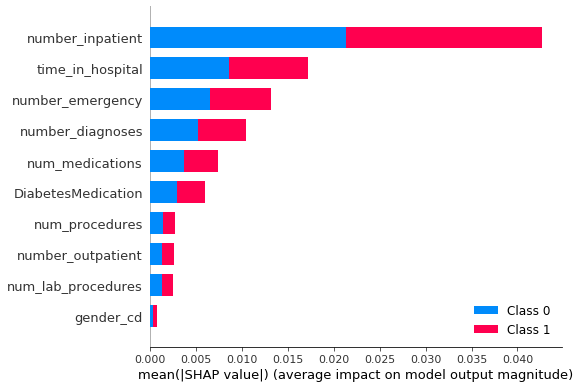

In [0]:
import shap
shap_values = shap.Explainer(rf).shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

In [0]:
# Get the predictions and put them with the test data.
X_output = X_test.copy()
X_output.loc[:,'predict'] = np.round(rf.predict_proba(X_output)[:, 1],2)

# Sort by highest to lowest predicted probability 
X_output_sorted= X_output.sort_values('predict',ascending=False)

# pick some observations
S2 = X_output_sorted.head(100)
S2

,time_in_hospital,num_procedures,num_lab_procedures,num_medications,number_outpatient,number_inpatient,number_emergency,number_diagnoses,gender_cd,DiabetesMedication,predict
85340,2,1,11,14,1,16,2,2,1,1,0.61
79467,1,0,11,8,0,12,5,7,1,1,0.61
85759,2,1,33,13,0,10,5,7,0,1,0.60
99950,2,0,11,9,2,12,3,5,1,1,0.57
51569,2,0,50,15,0,11,4,7,0,1,0.56
...,...,...,...,...,...,...,...,...,...,...,...
23293,12,0,75,23,0,7,2,9,1,1,0.40
100492,8,0,61,33,0,8,2,9,1,1,0.40
80099,2,0,35,15,0,8,20,9,1,1,0.40
98279,2,2,47,17,0,6,2,7,1,1,0.40


In [0]:
X_test_new = S2.drop(['predict'], axis=1)
wfall_exapliner = shap.Explainer(rf, X_test_new)
shap_values_waterfall = wfall_exapliner(X_test_new)

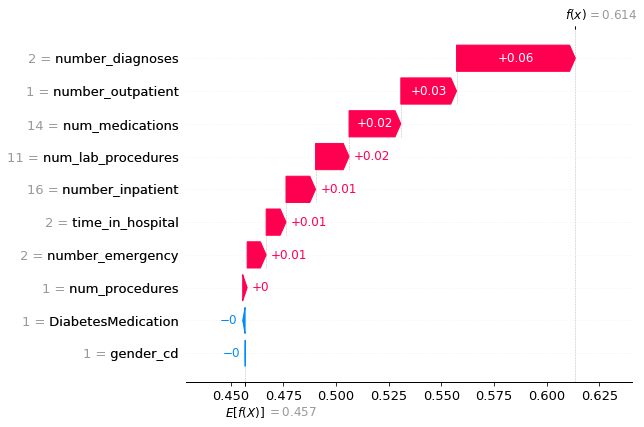

In [0]:
shap.plots.waterfall(shap_values_waterfall[0][:,1], max_display=20)

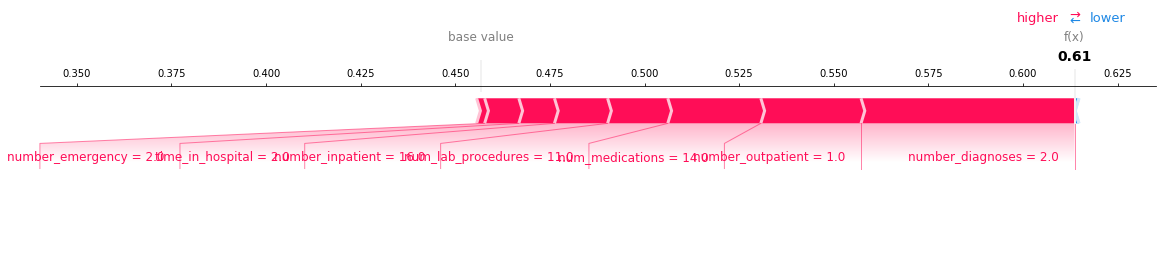

In [0]:
shap.plots.force(shap_values_waterfall[0][:,1], matplotlib=True)

In [0]:
column_names = X_test_new.columns.values.tolist()
column_names

Out[12]: ['time_in_hospital',
 'num_procedures',
 'num_lab_procedures',
 'num_medications',
 'number_outpatient',
 'number_inpatient',
 'number_emergency',
 'number_diagnoses',
 'gender_cd',
 'DiabetesMedication']

In [0]:
shap_values_waterfall[0][:,1]

Out[13]: .values =
array([ 9.41485629e-03, 2.11479094e-03, 1.59010075e-02, 2.45804685e-02,
 2.64677398e-02, 1.40373549e-02, 9.02816901e-03, 5.64090599e-02,
 -5.40269841e-05, -1.12639605e-03])

.base_values =
0.4568290352359673

.data =
array([ 2, 1, 11, 14, 1, 16, 2, 2, 1, 1], dtype=int32)